In [5]:
%cd ..
# !curl -L -o .\data\sprites.zip https://www.kaggle.com/api/v1/datasets/download/ebrahimelgazar/pixel-art
# !Expand-Archive -LiteralPath '.\data\sprites.zip'

C:\Users\daanw\PycharmProjects\BSc-Thesis


In [6]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from project.models import EDM

In [7]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

Using: cuda


In [8]:
PATH = os.path.join("data", "sprites")
BATCH_SIZE = 32

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=0.5,
        std=0.5
    )  # Normalize image between [-1, 1]
])

In [10]:
data = datasets.ImageFolder(
    root=PATH,
    transform=transform,
)
loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True)

In [11]:
image, y = data[50]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7882353].


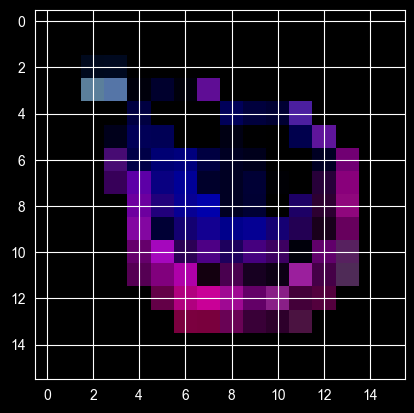

In [12]:
plt.imshow(image.permute((1, 2, 0)))
plt.show()

In [13]:
model = EDM(
    image_resolution=image.shape[1],
    image_channels=image.shape[0],
).to(device)

In [15]:
print(sum(p.numel() for p in model._score_network.parameters() if p.requires_grad))

258797413


In [ ]:
model.train(10, loader)

Epoch process:   0%|          | 0/2794 [00:00<?, ?it/s]C:\Users\daanw\PycharmProjects\BSc-Thesis\project\models\edm.py:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (1 / 4) * torch.log(torch.tensor(sigma, device=self._device))
Epoch process:   1%|          | 27/2794 [03:12<5:36:38,  7.30s/it]